# Name : Nihar Naringrekar     Roll No : 48        Date : 09/03/2026
## Exp 8 - Clustering of Countries with World Bank API

In [1]:
!pip install requests

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler 
from scipy.cluster.hierarchy import dendrogram, linkage

In [3]:
def fetch_indicator(code, year="2022"):
    url =  f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=30000"
    response = requests.get(url).json()[1]
    
    data = {}
    for item in response:
        country = item["country"]["value"]
        value = item["value"]
        if value is not None:
            data[country] = value
    return pd.Series(data,name=code)

In [4]:
gdp = fetch_indicator("NY.GDP.PCAP.CD")
pop= fetch_indicator("SP.POP.TOTL")
life = fetch_indicator("SP.DYN.LE00.IN")
lit = fetch_indicator("SE.ADT.LITR.ZS")

In [36]:
df = pd.concat([gdp, pop, life, lit], axis=1)

df.columns = ["GDP", "Population","LifeExpectancy", "Literacy"]

# df.dropna(inplace=True)

df.head()

,GDP,Population,LifeExpectancy,Literacy
Africa Eastern and Southern,1679.327622,731821393,64.487020,73.055977
Africa Western and Central,2138.473153,497387180,57.987813,60.780979
Arab World,7950.355820,471352066,71.876096,78.271927
Central Europe and the Baltics,19530.155323,100071871,76.652299,99.479919
Early-demographic dividend,4043.827763,3470644834,71.430455,81.242798


In [37]:
df.tail()

,GDP,Population,LifeExpectancy,Literacy
Uruguay,20818.614609,3390913,76.468,98.849998
Uzbekistan,2578.666894,34938955,72.147,100.000000
Viet Nam,4147.697772,99680655,74.502,96.129997
West Bank and Gaza,3799.955270,5043612,76.662,97.839996
Zambia,1447.123101,20152938,65.279,79.975143


In [38]:
df.sample(5)

,GDP,Population,LifeExpectancy,Literacy
Bahrain,30470.521928,1524693,80.992000,97.870003
Sub-Saharan Africa (excluding high income),1963.803300,1103704408,61.283354,68.148750
Middle income,6248.009620,5846464711,72.517202,87.295677
Europe & Central Asia (IDA & IBRD countries),11421.136443,460942269,74.188365,99.328468
Honduras,3003.289968,10463872,72.715000,88.276415


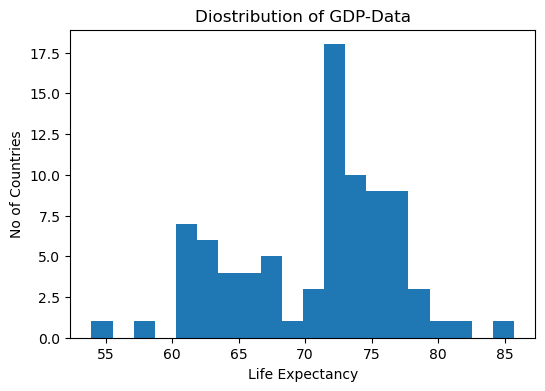

In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

plt.figure(figsize=(6,4))
plt.hist(df["LifeExpectancy"], bins=20)
plt.xlabel("Life Expectancy")
plt.ylabel("No of Countries")
plt.title("Diostribution of GDP-Data")
plt.show()

In [40]:
country_name = "India"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectation:", result["LifeExpectancy"])
print("Literacy Rate:", result["Literacy"])

Country: India
GDP per capita: 2347.44829434623
Population: 1425423212.0
Life Expectation: 71.698
Literacy Rate: 76.3199996948242


In [41]:
country_name = "North America"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectation:", result["LifeExpectancy"])
print("Literacy Rate:", result["Literacy"])

Country: North America
GDP per capita: 74535.6365392629
Population: 373018004.0
Life Expectation: 77.8327679594239
Literacy Rate: 98.7891464233398


In [42]:
country_name = "Brazil"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectation:", result["LifeExpectancy"])
print("Literacy Rate:", result["Literacy"])

Country: Brazil
GDP per capita: 9281.33282136864
Population: 210306415.0
Life Expectation: 74.872
Literacy Rate: 94.3853874531348


In [45]:
country_name = "Viet Nam"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectation:", result["LifeExpectancy"])
print("Literacy Rate:", result["Literacy"])

Country: Viet Nam
GDP per capita: 4147.69777213621
Population: 99680655.0
Life Expectation: 74.502
Literacy Rate: 96.129997253418


In [46]:
country_name = "Bahrain"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectation:", result["LifeExpectancy"])
print("Literacy Rate:", result["Literacy"])

Country: Bahrain
GDP per capita: 30470.5219276023
Population: 1524693.0
Life Expectation: 80.992
Literacy Rate: 97.870002746582


In [47]:
df = pd.concat([gdp, pop, life, lit], axis=1)

df.columns = ["GDP", "Population","LifeExpectancy", "Literacy"]

df.dropna(inplace=True)

df.head()

,GDP,Population,LifeExpectancy,Literacy
Africa Eastern and Southern,1679.327622,731821393,64.487020,73.055977
Africa Western and Central,2138.473153,497387180,57.987813,60.780979
Arab World,7950.355820,471352066,71.876096,78.271927
Central Europe and the Baltics,19530.155323,100071871,76.652299,99.479919
Early-demographic dividend,4043.827763,3470644834,71.430455,81.242798


#### Eblow Method

In [48]:
wcss = []

for k in range(1,11):
    km = KMeans(n_clusters=k, random_state = 0)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    
print("k\tWCSS")
for i in range(10):
    print(i+1 , "\t", wcss[i])


k	WCSS
1 	 336.0
2 	 206.43717192603816
3 	 142.06028324967593
4 	 122.4640064142117
5 	 68.71234707726032
6 	 56.092718405819134
7 	 51.08265517326419
8 	 41.70851027024397
9 	 31.213863029560216
10 	 27.047250986507716


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

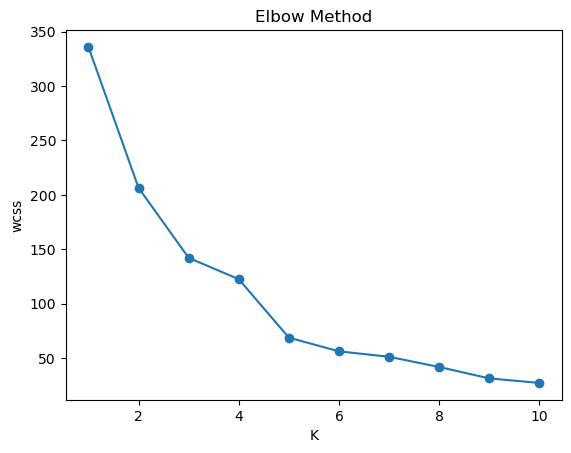

In [49]:
plt.plot(range(1,11),wcss,marker="o")
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("wcss")
plt.show()

#### Agglomerative (Hierarchical) Clustering

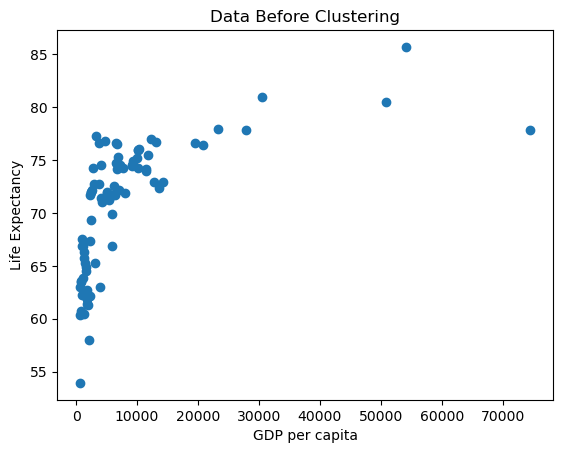

In [50]:
plt.scatter(df["GDP"],df["LifeExpectancy"])
plt.title("Data Before Clustering")
plt.xlabel("GDP per capita")
plt.ylabel("Life Expectancy")
plt.show()

In [51]:
kmeans = KMeans(n_clusters=3, random_state = 0)

labels_km = kmeans.fit_predict(X_scaled)
df["KMEansClusters"] = labels_km

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [52]:
df.head(10)

,GDP,Population,LifeExpectancy,Literacy,KMEansClusters
Africa Eastern and Southern,1679.327622,731821393,64.487020,73.055977,0
Africa Western and Central,2138.473153,497387180,57.987813,60.780979,0
Arab World,7950.355820,471352066,71.876096,78.271927,1
Central Europe and the Baltics,19530.155323,100071871,76.652299,99.479919,1
Early-demographic dividend,4043.827763,3470644834,71.430455,81.242798,2
East Asia & Pacific,13139.210981,2379617118,76.676717,96.363121,1
East Asia & Pacific (excluding high income),10106.993598,2133560408,75.932541,96.592010,1
East Asia & Pacific (IDA & IBRD countries),10220.477443,2107261123,75.961035,96.549141,1
Europe & Central Asia,27913.588233,924234471,77.834479,98.749657,1
Europe & Central Asia (excluding high income),7266.022432,250514347,74.573168,98.906059,1


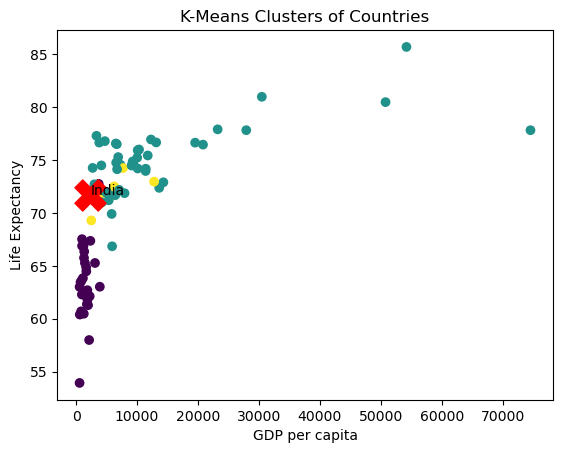

In [53]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c=labels_km)
plt.title("K-Means Clusters of Countries")
plt.xlabel("GDP per capita")
plt.ylabel("Life Expectancy")

india = df.loc["India"]
plt.scatter(india ["GDP"], india ["LifeExpectancy"],
        s=500,color='Red',marker='X')
plt.text(india ["GDP"], india["LifeExpectancy"], "India")

plt.show()


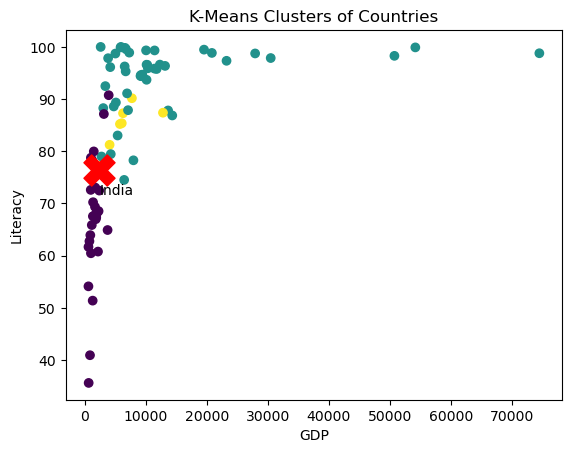

In [54]:
plt.scatter(df["GDP"], df["Literacy"], c=labels_km)
plt.title("K-Means Clusters of Countries")
plt.xlabel("GDP")
plt.ylabel("Literacy")

india = df.loc["India"]
plt.scatter(india ["GDP"], india ["Literacy"],
        s=500,color='Red',marker='X')
plt.text(india ["GDP"], india["LifeExpectancy"], "India")

plt.show()

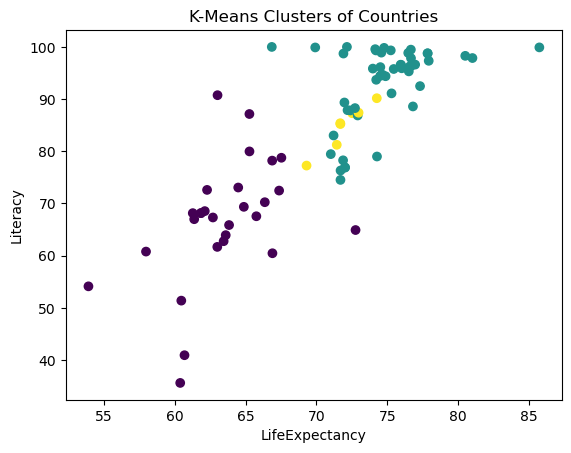

In [55]:
plt.scatter(df["LifeExpectancy"], df["Literacy"], c=labels_km)
plt.title("K-Means Clusters of Countries")
plt.xlabel("LifeExpectancy")
plt.ylabel("Literacy")

plt.show()

In [56]:
cluster_summary = df.groupby("KMEansClusters")[["GDP", "Population", "LifeExpectancy", "Literacy"]].mean()
print(cluster_summary)

                         GDP    Population  LifeExpectancy   Literacy
KMEansClusters                                                       
0                1601.971896  4.854521e+08       63.478867  66.779721
1               12288.225626  4.669122e+08       74.753258  92.910908
2                6437.349751  5.501554e+09       71.975830  84.851687


In [57]:
hc = AgglomerativeClustering(n_clusters=3)

label_hc = hc.fit_predict(X_scaled)
df["HierarchicalCluster"] = label_hc
df.head(5)

,GDP,Population,LifeExpectancy,Literacy,KMEansClusters,HierarchicalCluster
Africa Eastern and Southern,1679.327622,731821393,64.487020,73.055977,0,1
Africa Western and Central,2138.473153,497387180,57.987813,60.780979,0,1
Arab World,7950.355820,471352066,71.876096,78.271927,1,1
Central Europe and the Baltics,19530.155323,100071871,76.652299,99.479919,1,0
Early-demographic dividend,4043.827763,3470644834,71.430455,81.242798,2,1


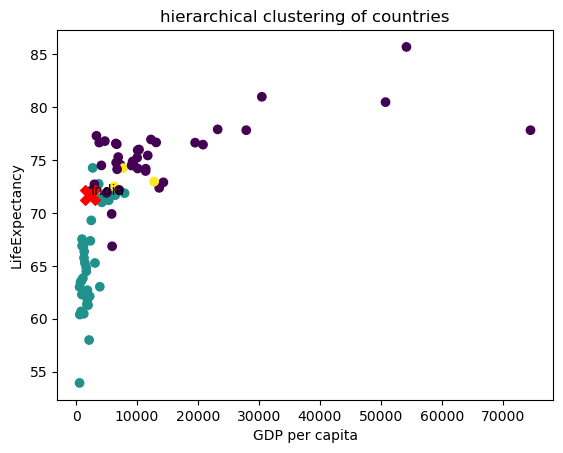

In [58]:
plt.scatter(df["GDP"],df["LifeExpectancy"],c=label_hc)

plt.xlabel("GDP per capita")
plt.ylabel("LifeExpectancy")
plt.title("hierarchical clustering of countries")
india = df.loc["India"]
plt.scatter (india ["GDP"],india["LifeExpectancy"],
            s=200,color='Red',marker='X')

plt.text(india["GDP"],india["LifeExpectancy"],"India")

plt.show()

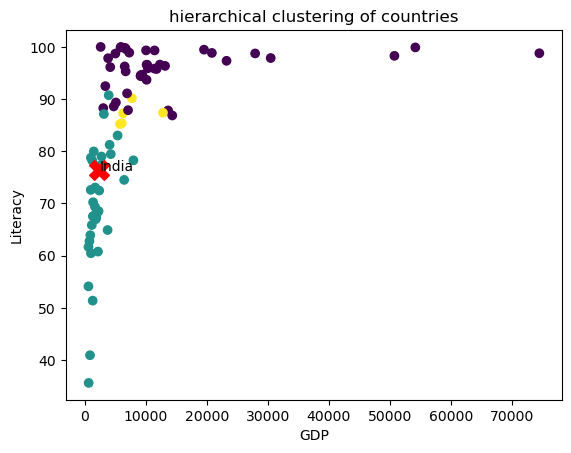

In [59]:
plt.scatter(df["GDP"],df["Literacy"],c=label_hc)

plt.xlabel("GDP")
plt.ylabel("Literacy")
plt.title("hierarchical clustering of countries")
india = df.loc["India"]
plt.scatter (india ["GDP"],india["Literacy"],
            s=200,color='Red',marker='X')

plt.text(india["GDP"],india["Literacy"],"India")

plt.show()

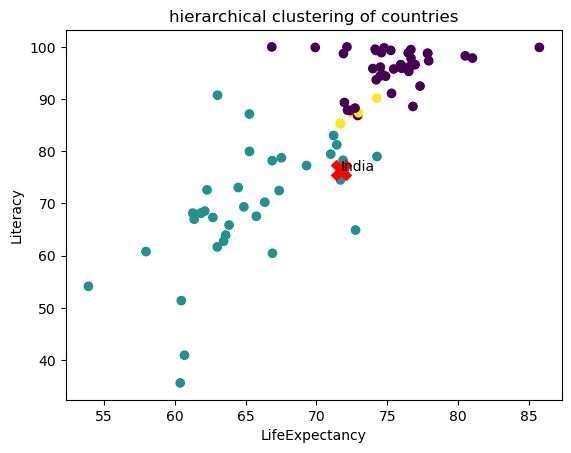

In [60]:
plt.scatter(df["LifeExpectancy"],df["Literacy"],c=label_hc)

plt.xlabel("LifeExpectancy")
plt.ylabel("Literacy")
plt.title("hierarchical clustering of countries")
india = df.loc["India"]
plt.scatter (india ["LifeExpectancy"],india["Literacy"],
            s=200,color='Red',marker='X')

plt.text(india["LifeExpectancy"],india["Literacy"],"India")

plt.show()